# Relativistic Boris-C Particle Simulation in Earth's Dipole Field

In [14]:
import sys
import os
sys.path.insert(0, os.path.abspath('.'))

from REL_BORIS_C_DIPOLE import init_cond, run_simulation, plot_results

## 1–Physical Setup

### Magnetic field

Earth's dipole field with a **11.7° geographic–geomagnetic tilt**:

$$\mathbf{B}(\mathbf{r}) = -\frac{M_E}{r^5}\left[3(\hat{\mathbf{m}}\cdot\mathbf{r})\,\mathbf{r} - r^2\hat{\mathbf{m}}\right]$$

where $\hat{\mathbf{m}}$ is the magnetic moment and  $M_E = 7.97\times10^{15}\;\text{T\,m}^3$

### Particles

We simulate three particles:

| Particle | Speed ($\beta$) | Kinetic energy | $x_0$ |
|:---------|:--------------:|:--------------:|:------:|
| Proton        | $0.616\,c$ | ~252 MeV | $2.5\,R_E$ |
| Electron      | $0.94\,c$  | ~1 MeV   | $4.5\,R_E$ |
| Alpha particle | $0.50\,c$  | ~577 MeV | $2.5\,R_E$ |

All particles start at $y = z = 0$ on the equatorial plane with equatorial pitch angle
$\alpha_{eq} = 60°$:

$$v_y = v\sin\alpha_{eq} \;(\perp\mathbf{B}), \qquad v_z = v\cos\alpha_{eq} \;(\|\mathbf{B})$$

### Integration parameters

Timesteps and simulation durations are chosen per particle to resolve several gyrations and bounce cycles:

| Particle | $dt$ [s] | $T_{\rm sim}$ [s] | stored every |
|:---------|:--------:|:-----------------:|:------------:|
| Proton        | $10^{-4}$ | 6.0 | 10 steps |
| Electron      | $10^{-5}$ | 0.6 | 10 steps |
| Alpha particle | $10^{-4}$ | 6.0 | 10 steps |

In [15]:
particles = init_cond(alpha_eq_deg=30.0)

## 2–Running the Simulation

Each particle is integrated twice: once with **Boris-C** (full trajectory stored) and once with
**RK4** (only initial and final $\gamma$ stored, for the energy comparison).
Progress bars show both passes per particle.

In [16]:
results = run_simulation(particles)

RK4      Alpha particle: 100%|██████████| 60000/60000 [00:03<00:00, 15549.82it/s]


  Particle         Method     gamma_0 gamma_final gamma_error
  ───────────────────────────────────────────────────────────
  Proton           Boris-C     1.2694     1.2694   6.65e-15
                   RK4         1.2694     1.2694   9.51e-07
  Electron         Boris-C     2.9311     2.9311   1.52e-16
                   RK4         2.9311 999999999999999.8750   3.41e+14
  Alpha particle   Boris-C     1.1547     1.1547   1.92e-16
                   RK4         1.1547     1.1537   8.91e-04



### Energy conservation: Boris-C vs. RK4

The table reports the relative Lorentz factor error $|\Delta\gamma/\gamma_0|$ at the end of each run.

## 3–Trajectories

Each particle is plotted individually. Every panel includes a 3D trajectory and the equatorial ($xy$) and meridional ($xz$) projections,

### Proton — $250 \text{MeV}, L = 2.5\,R_E$

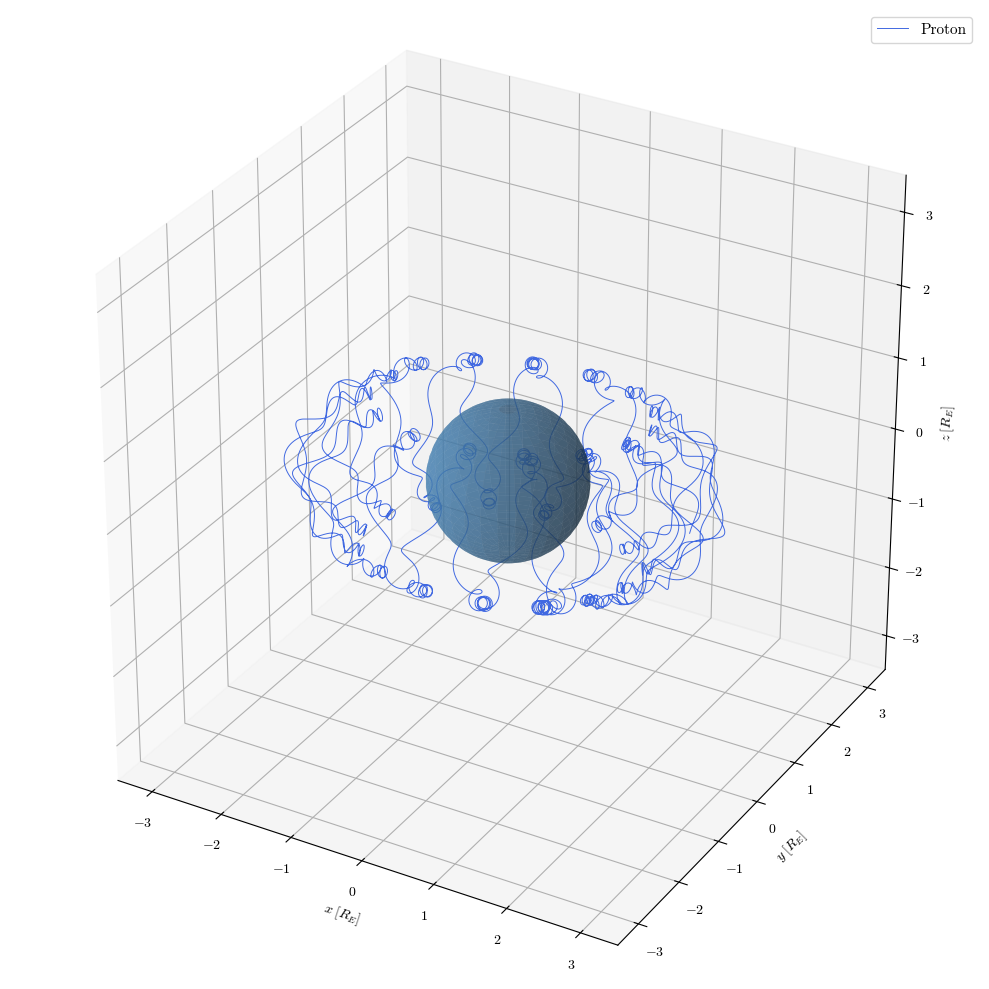

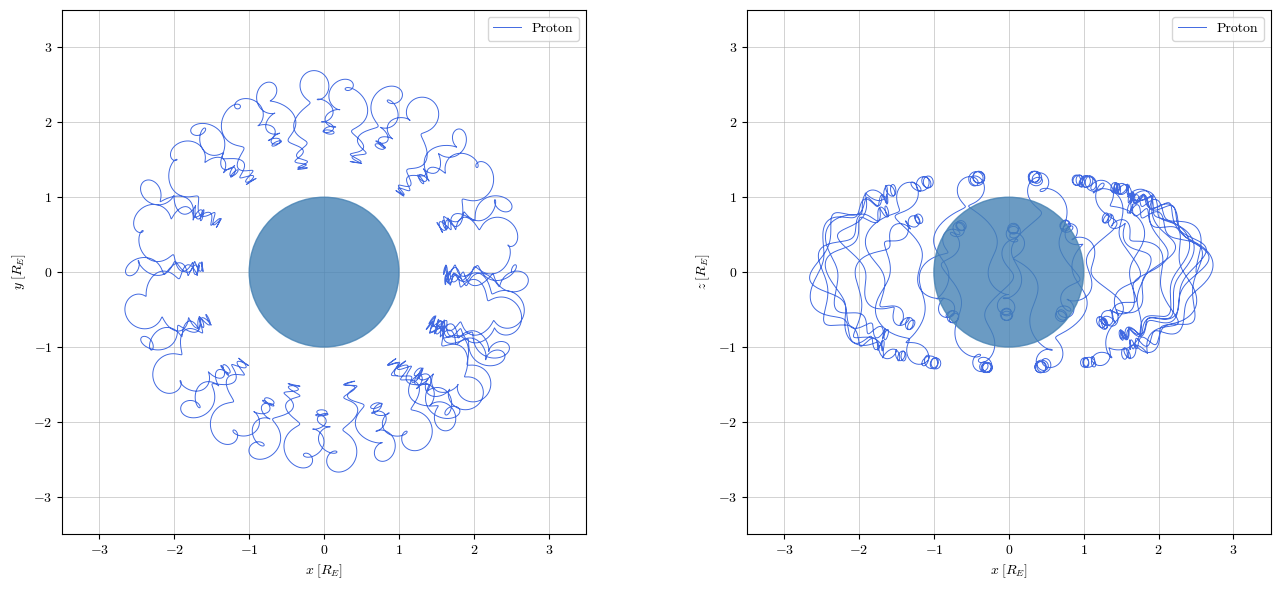

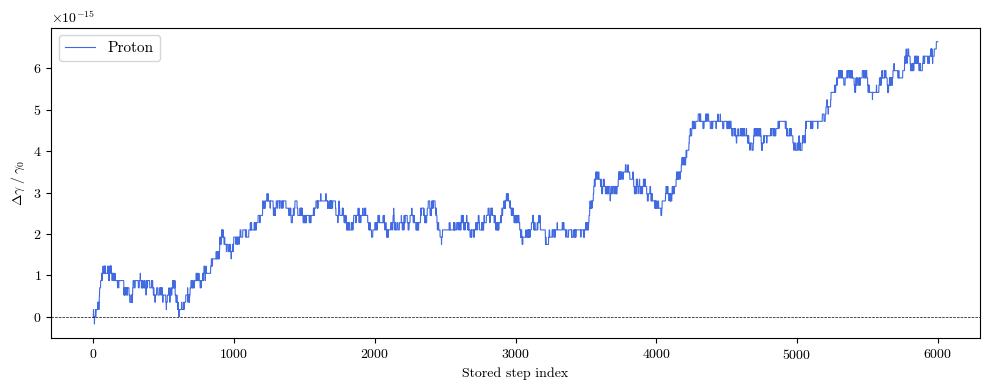

In [17]:
plot_results({'Proton': results['Proton']}, save=False, lim=3.5)

### Electron — 1 MeV, $L = 4.5\,R_E$

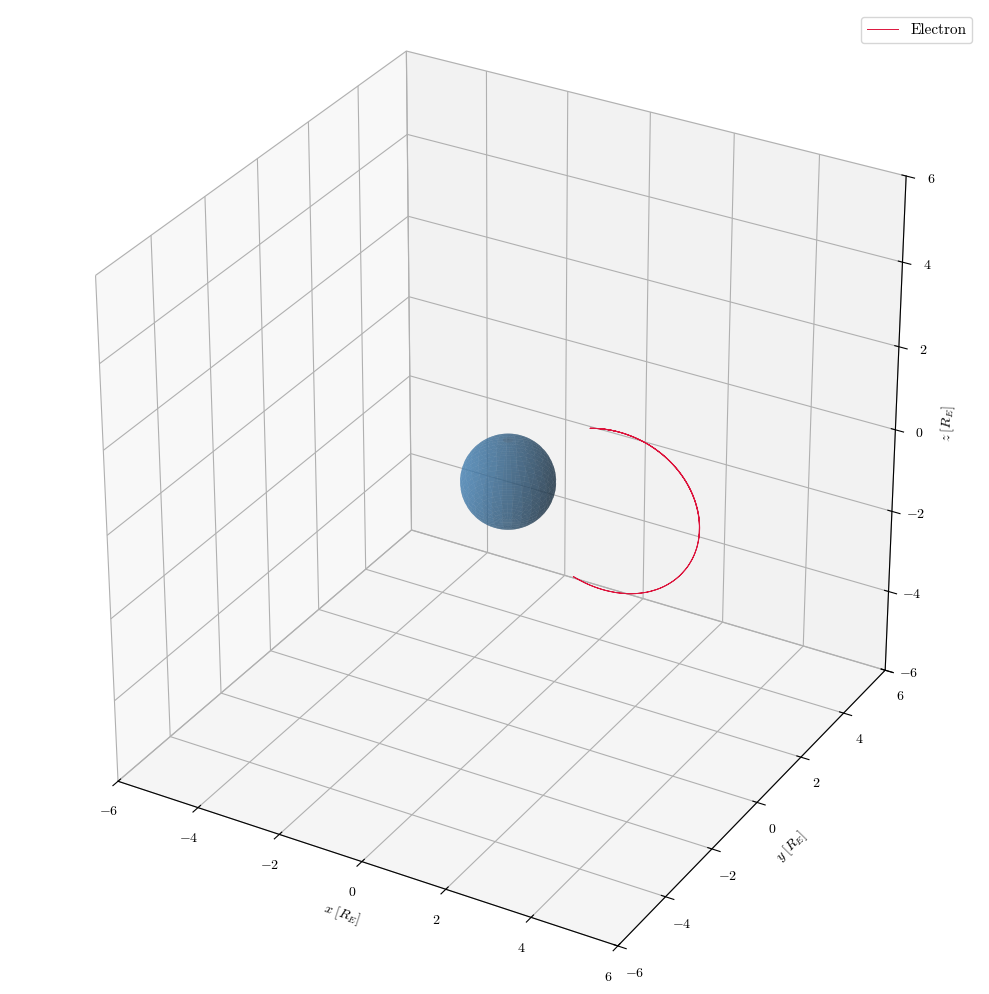

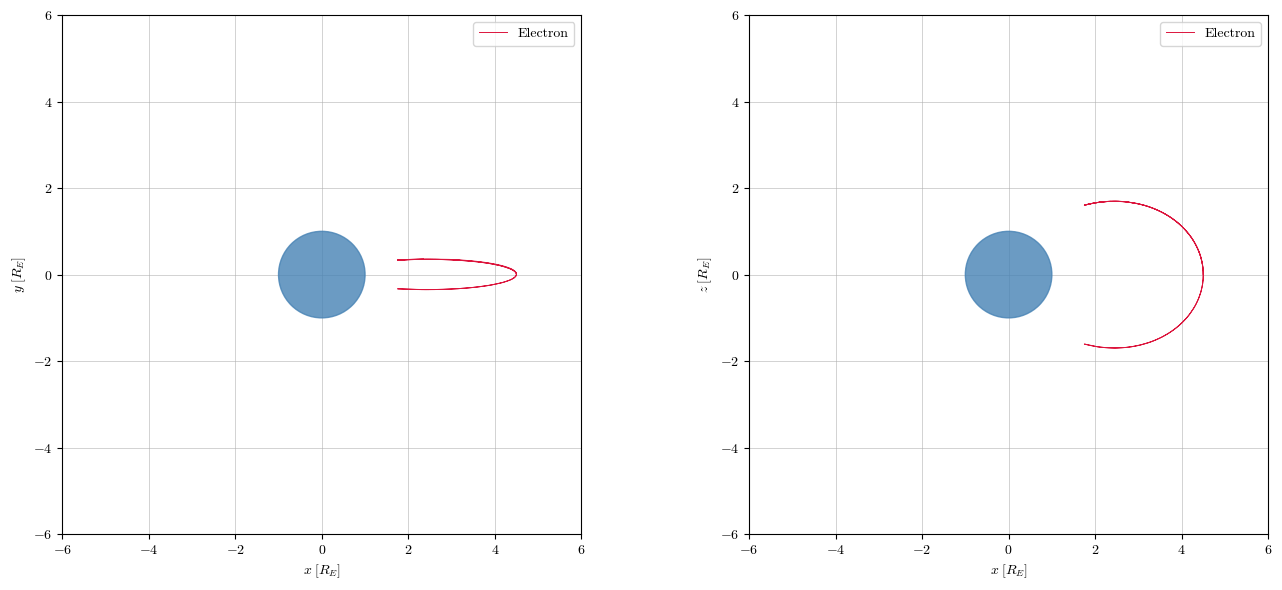

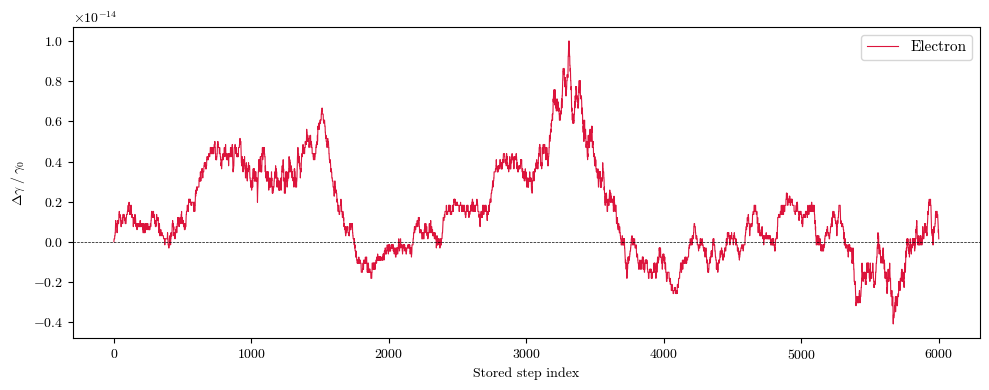

In [18]:
plot_results({'Electron': results['Electron']}, save=False, lim=6)

### Alpha particle — ~577 MeV, $L = 2.5\,R_E$

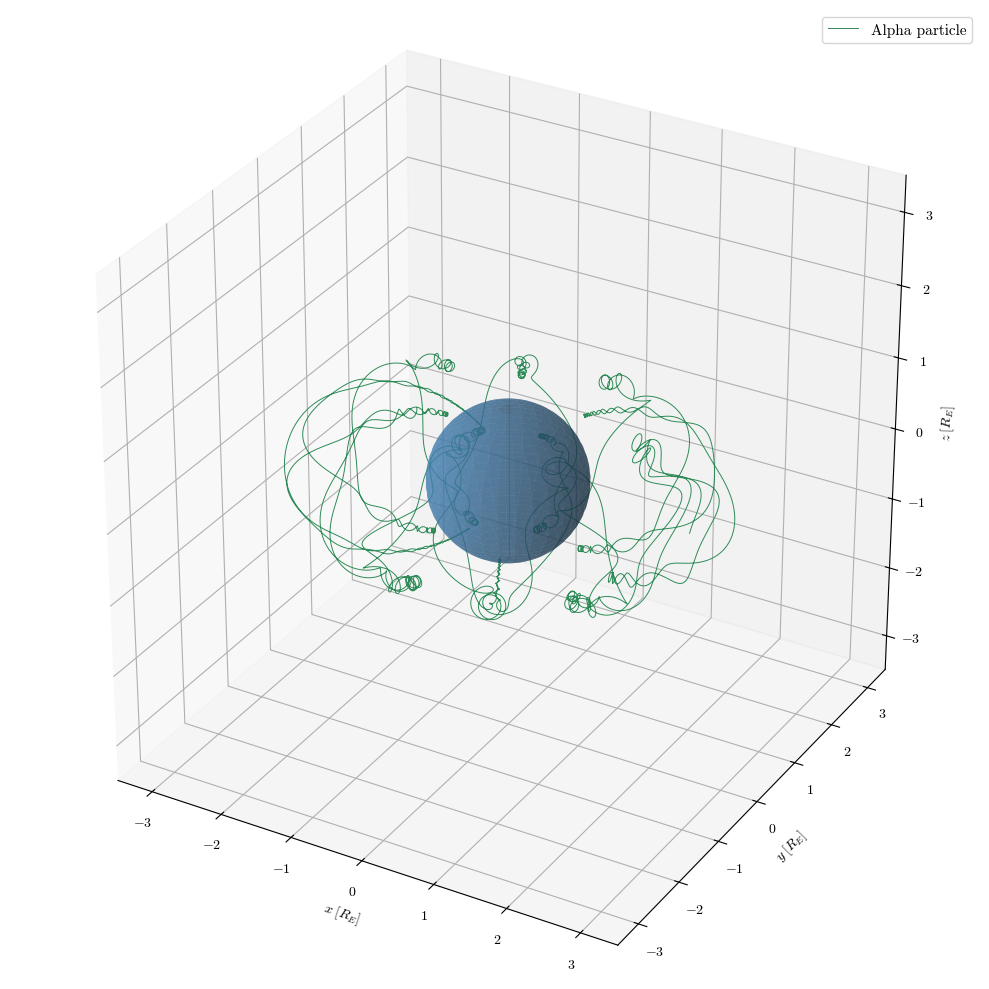

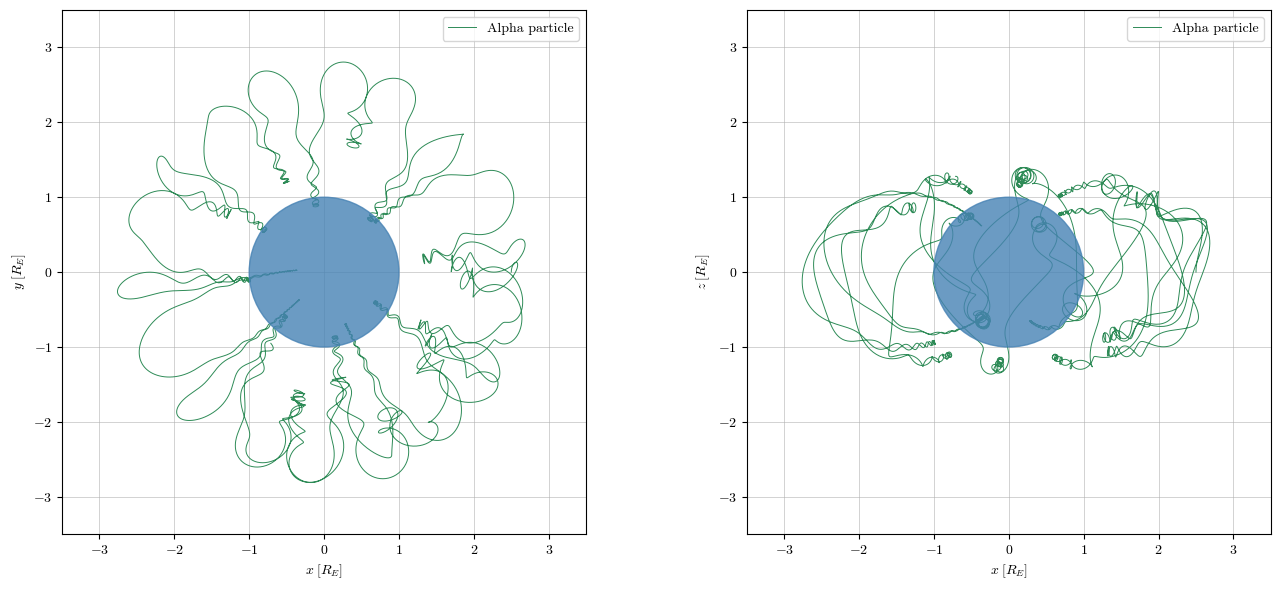

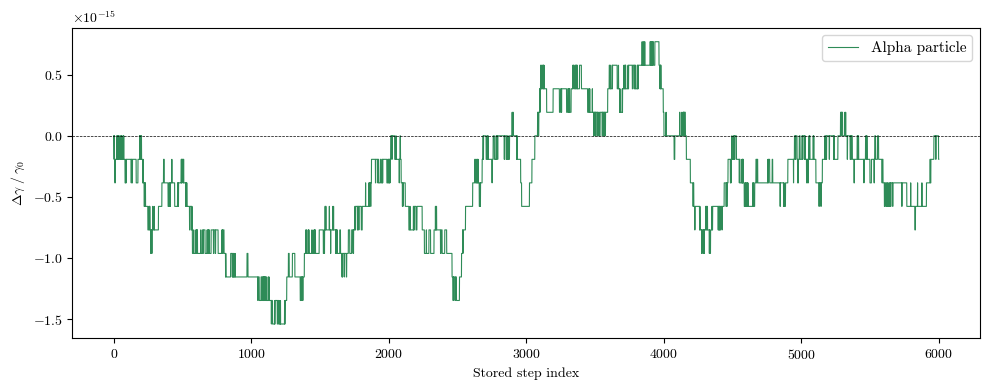

In [20]:
plot_results({'Alpha particle': results['Alpha particle']}, save=False, lim=3.5)

## 4–Conclusion